In [1]:
!pip install timm -q
!git clone https://github.com/emanhamed/Houses-dataset.git

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import timm
import os
import warnings
warnings.filterwarnings('ignore')

print(f"GPU: {torch.cuda.is_available()}")

fatal: destination path 'Houses-dataset' already exists and is not an empty directory.
GPU: True


In [2]:
IMG_DIR = "Houses-dataset/Houses Dataset/"
IMG_TYPES = ['frontal', 'bedroom', 'bathroom', 'kitchen']

df = pd.read_csv(
    "Houses-dataset/Houses Dataset/HousesInfo.txt",
    header=None, sep=' ',
    names=['bedrooms', 'bathrooms', 'area', 'zipcode', 'price']
)

y = np.log1p(df['price'].values)
tab_features = df[['bedrooms', 'bathrooms', 'area', 'zipcode']].values
scaler = StandardScaler()
tab_features = scaler.fit_transform(tab_features)

all_indices = np.arange(len(df))
idx_train, idx_temp = train_test_split(all_indices, test_size=0.3, random_state=42)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.5, random_state=42)

print(f"Tabular features: {tab_features.shape[1]}")
print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")
print("Data loaded")

Tabular features: 4
Train: 374 | Val: 80 | Test: 81
Data loaded


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class MultimodalHouseDataset(Dataset):
    def __init__(self, indices, tab_features, targets, img_dir, transform):
        self.indices      = indices
        self.tab_features = tab_features
        self.targets      = targets
        self.img_dir      = img_dir
        self.transform    = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        house_idx = self.indices[idx]

        # Load & average 4 images
        imgs = []
        for img_type in IMG_TYPES:
            path = os.path.join(self.img_dir, f"{house_idx+1}_{img_type}.jpg")
            img = Image.open(path).convert('RGB')
            imgs.append(self.transform(img))
        img_tensor = torch.stack(imgs).mean(dim=0)

        # Tabular features
        tab_tensor = torch.FloatTensor(self.tab_features[house_idx])

        # Target
        target = torch.tensor(self.targets[house_idx], dtype=torch.float32)

        return img_tensor, tab_tensor, target

train_ds = MultimodalHouseDataset(idx_train, tab_features, y, IMG_DIR, transform)
val_ds   = MultimodalHouseDataset(idx_val,   tab_features, y, IMG_DIR, transform)
test_ds  = MultimodalHouseDataset(idx_test,  tab_features, y, IMG_DIR, transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2)

print("Multimodal DataLoaders ready")

Multimodal DataLoaders ready


In [4]:
class MultimodalFusionModel(nn.Module):
    def __init__(self, tab_input_dim=4):
        super().__init__()

        # Image branch — ViT-B/16
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        self.img_projector = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Tabular branch — MLP
        self.tab_projector = nn.Sequential(
            nn.Linear(tab_input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Late fusion head — concatenate both branches
        self.fusion_head = nn.Sequential(
            nn.Linear(256 + 256, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, img, tab):
        img_feat = self.img_projector(self.vit(img))
        tab_feat = self.tab_projector(tab)
        fused    = torch.cat([img_feat, tab_feat], dim=1)
        return self.fusion_head(fused).squeeze(1)

model_mm = MultimodalFusionModel(tab_input_dim=4).cuda()
total_params = sum(p.numel() for p in model_mm.parameters())
print(f"Total parameters: {total_params:,}")
print("Multimodal fusion model ready")

Total parameters: 86,160,321
Multimodal fusion model ready


In [9]:
# Set seeds for reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)

EPOCHS = 30
best_overall_loss = float('inf')

for run in range(3):  # train 3 times, keep best
    # Reinitialize model fresh each run
    model_mm = MultimodalFusionModel(tab_input_dim=4).cuda()
    optimizer = torch.optim.AdamW([
        {'params': model_mm.vit.parameters(),           'lr': 1e-5},
        {'params': model_mm.img_projector.parameters(), 'lr': 1e-4},
        {'params': model_mm.tab_projector.parameters(), 'lr': 1e-4},
        {'params': model_mm.fusion_head.parameters(),   'lr': 1e-4}
    ], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')

    print(f"\n=== Run {run+1}/3 ===")
    for epoch in range(EPOCHS):
        train_loss = train_epoch_mm(model_mm, train_loader, optimizer, criterion)
        val_loss   = eval_epoch_mm(model_mm, val_loader, criterion)
        scheduler.step()
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            if best_val_loss < best_overall_loss:
                best_overall_loss = best_val_loss
                torch.save(model_mm.state_dict(), 'best_multimodal_model.pt')

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] Train: {train_loss:.4f} | Val: {val_loss:.4f}")

print(f"\nBest overall val loss: {best_overall_loss:.4f}")
print("Training complete")


=== Run 1/3 ===
Epoch [10/30] Train: 1.6943 | Val: 0.7755
Epoch [20/30] Train: 1.2456 | Val: 0.5711
Epoch [30/30] Train: 1.0439 | Val: 0.5604

=== Run 2/3 ===
Epoch [10/30] Train: 1.5579 | Val: 0.8291
Epoch [20/30] Train: 1.4069 | Val: 0.4928
Epoch [30/30] Train: 1.4772 | Val: 0.5819

=== Run 3/3 ===
Epoch [10/30] Train: 1.7372 | Val: 0.6093
Epoch [20/30] Train: 1.3609 | Val: 0.5307
Epoch [30/30] Train: 1.2122 | Val: 0.5210

Best overall val loss: 0.4623
Training complete


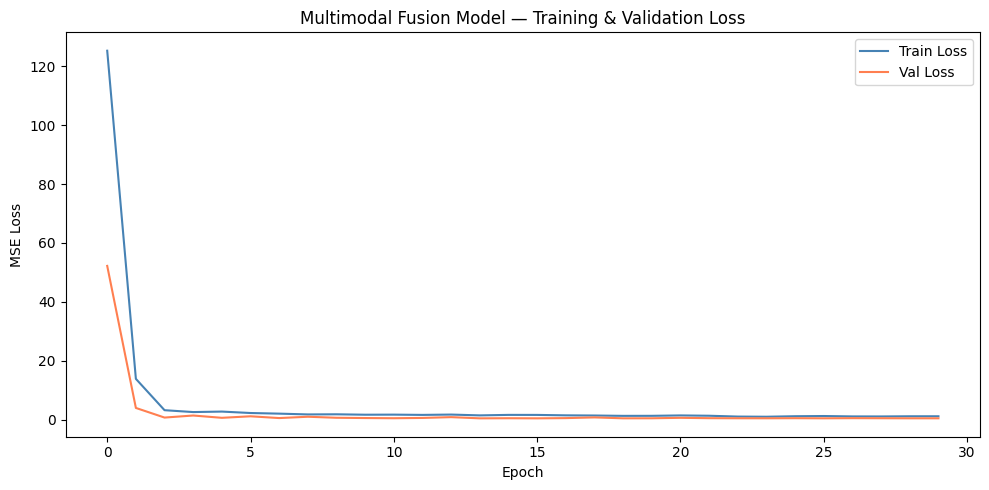

=== Multimodal Fusion Results ===
RMSE: $267,434.63
MAE:  $201,047.17
R²:   0.4012


In [10]:
# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses, label='Val Loss', color='coral')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Multimodal Fusion Model — Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('multimodal_loss_curve.png', dpi=150)
plt.show()

# Evaluate on test set
model_mm.load_state_dict(torch.load('best_multimodal_model.pt'))
model_mm.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, tabs, targets in test_loader:
        imgs, tabs = imgs.cuda(), tabs.cuda()
        preds = model_mm(imgs, tabs).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(targets.numpy())

all_preds   = np.expm1(np.array(all_preds))
all_targets = np.expm1(np.array(all_targets))

rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
mae  = mean_absolute_error(all_targets, all_preds)
r2   = r2_score(all_targets, all_preds)

print("=== Multimodal Fusion Results ===")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"R²:   {r2:.4f}")

In [11]:
# Run this RIGHT NOW
torch.save(model_mm.state_dict(), 'best_multimodal_model.pt')
from google.colab import files
files.download('best_multimodal_model.pt')
print("Model saved and downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved and downloaded
